# Set pieces / breaks in play: repeatability and transition timing

*Using Projective Transformation for the Spatial Analysis of Team Behaviors in Football*

For phases of relative inactivity - set pieces and breaks in play - this notebook verifies the repeatability of players' positional structures across multiple instances of the same restart type, and measures the time taken for a team to transition from a static to a dynamic formation after the restart of play.

Unlike the previous two phase notebooks, **this one needs several clips of the same restart type** (e.g. multiple corners taken from the same side), not just one - repeatability is a comparison *across* instances. It runs the shared pipeline (see `00_pipeline_demo.ipynb`/`01_goal_scoring_opportunity.ipynb` for the step-by-step walkthroughs) once per clip, then:

1. **Static-to-dynamic transition timing**: detects the restart of play from the ball's movement onset, then measures how long the analysed team took to go from standing still to moving as a group.
2. **Repeatability of positional structures**: compares the team's static formation (positions just before each restart) across instances, using optimal point-set matching (no player re-identification needed) rather than assuming any particular player identity carries between clips.

## 1. Setup

**If you've already run a notebook earlier in the current Colab session** and are re-pulling newer code: Python caches `pitchvision` in memory after the first `import`, so a `git pull` alone won't pick up new/changed symbols in already-running cells. After pulling, use **Runtime > Restart session**, then **Run all** - the commit hash printed below should match the latest commit on GitHub.

In [4]:
import os
import sys

REPO_URL = "https://github.com/Batomet/Magisterka.git"
BRANCH = "claude/football-spatial-analysis-thesis-lx13x7"
REPO_DIR = "/content/Magisterka"

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git pull
!git log -1 --oneline

# Put the package on sys.path directly, rather than relying on `pip install -e .`
# to register it - editable installs use a .pth/import-finder file that Python's
# site module only processes at interpreter startup, so one run mid-session (in
# an already-running Colab kernel) doesn't reliably become importable.
SRC_DIR = os.path.join(REPO_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

/content/Magisterka
Already up to date.
10cff6e (HEAD -> claude/football-spatial-analysis-thesis-lx13x7, origin/claude/football-spatial-analysis-thesis-lx13x7, origin/HEAD) Add set pieces analysis: transition timing + formation repeatability


In [5]:
!pip install -q -r requirements.txt

## 2. Mount Drive and pick set-piece instances

Pick clips of the **same restart type** (e.g. all corners taken from the same side, or all free kicks from a similar position) by watching them first - repeatability across genuinely different restart types isn't a meaningful comparison. Adjust the indices below to match what you find in your `SetPieces` folder.

In [6]:
from pitchvision import DriveConfig, list_videos, mount_drive

mount_drive()

# Adjust `root` if BuildingAction/Goals/SetPieces don't live directly under My Drive.
drive_cfg = DriveConfig(root="/content/drive/MyDrive/Magisterka")
set_piece_videos = list_videos(drive_cfg.set_pieces_path)
print(f"Found {len(set_piece_videos)} videos in SetPieces/")
for i, path in enumerate(set_piece_videos):
    print(i, os.path.basename(path))

Mounted at /content/drive
Found 16 videos in SetPieces/
0 SetPieces00011435.mp4
1 SetPieces00028119.mp4
2 SetPieces00033900.mp4
3 SetPieces00041270.mp4
4 SetPieces00065881.mp4
5 SetPieces00073436.mp4
6 SetPieces00074052.mp4
7 SetPieces00108476.mp4
8 SetPieces00120361.mp4
9 SetPieces00125546.mp4
10 SetPieces00130640.mp4
11 SetPieces00133911.mp4
12 SetPieces00135190.mp4
13 SetPieces00144830.mp4
14 SetPieces00151870.mp4
15 SetPieces00167369.mp4


In [7]:
# EDIT THIS: indices of clips that are the SAME restart type (watch them first).
instance_videos = set_piece_videos[:4]
instance_videos

['/content/drive/MyDrive/Magisterka/SetPieces/SetPieces00011435.mp4',
 '/content/drive/MyDrive/Magisterka/SetPieces/SetPieces00028119.mp4',
 '/content/drive/MyDrive/Magisterka/SetPieces/SetPieces00033900.mp4',
 '/content/drive/MyDrive/Magisterka/SetPieces/SetPieces00041270.mp4']

## 3. Shared pipeline setup

Downloaded once and reused across every clip below (pitch calibration and player detection weights don't need re-downloading per clip; team classification and tracking do need to be re-fit per clip, since jersey colours and player positions are naturally different in every clip).

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pitchvision import (
    PitchKeypointDetector,
    PlayerBallDetector,
    PlayerTracker,
    SPORTS_DETECTION_CLASSES,
    TeamClassifier,
    TrackingPipeline,
    VideoFrames,
    collect_jersey_samples,
    compute_formation_repeatability,
    compute_transition_time,
    download_pitch_keypoint_weights,
    download_player_detection_weights,
    draw_pitch,
    extract_static_formation,
    pick_team_by_swatch_color,
    plot_formations,
    plot_team_speed_timeline,
)

pitch_weights_path = download_pitch_keypoint_weights(
    "/content/drive/MyDrive/pitchvision_models/football-pitch-detection.pt"
)
keypoint_detector = PitchKeypointDetector(weights=pitch_weights_path, confidence=0.5)

player_weights_path = download_player_detection_weights(
    "/content/drive/MyDrive/pitchvision_models/football-player-detection.pt"
)
print("Shared weights ready.")

Shared weights ready.


## 4. Identify the team to track consistently across clips

`TeamClassifier` is fit independently for each clip, so cluster id `0`/`1` isn't guaranteed to mean the same real team from one clip to the next. Fit it once on the first instance, note the RGB swatch of the team you want to follow, and use `pick_team_by_swatch_color` in every clip afterwards to consistently resolve "which cluster id is that team" rather than assuming id `0` always means the same team.

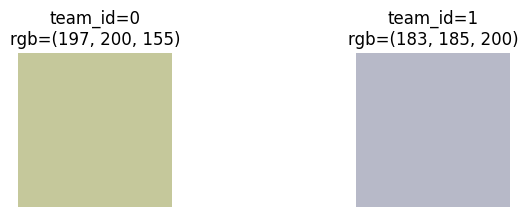

In [9]:
def fit_team_classifier_for_clip(video_path):
    detector = PlayerBallDetector(
        weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280
    )
    samples = collect_jersey_samples(video_path, detector, class_names=("player",), stride=10)
    classifier = TeamClassifier(n_clusters=2)
    classifier.fit(np.array([s.color for s in samples]))
    return classifier


preview_classifier = fit_team_classifier_for_clip(instance_videos[0])
swatches = preview_classifier.cluster_swatches

fig, axes = plt.subplots(1, len(swatches), figsize=(4 * len(swatches), 2))
for team_id, (ax, rgb) in enumerate(zip(axes, swatches)):
    ax.imshow([[rgb]])
    ax.set_title(f"team_id={team_id}\nrgb={rgb}")
    ax.axis("off")
plt.show()

In [10]:
# EDIT THIS: pick whichever swatch above matches the team you want to track
# across all instances.
REFERENCE_TEAM_RGB = swatches[0]
REFERENCE_TEAM_RGB

(197, 200, 155)

## 5. Process each instance

In [12]:
def analyze_set_piece_clip(video_path, reference_team_rgb):
    frames = VideoFrames(video_path)
    first_frame = frames.read_frame(0)
    fps = frames.fps

    calibrator = keypoint_detector.calibrate(first_frame)

    team_classifier = fit_team_classifier_for_clip(video_path)
    team_id = pick_team_by_swatch_color(team_classifier.cluster_swatches, reference_team_rgb)

    tracker = PlayerTracker(
        weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280
    )
    pipeline = TrackingPipeline(
        tracker=tracker,
        calibrator=calibrator,
        team_classifier=team_classifier,
        team_eligible_class_names=("player",),
    )
    tracks_df = pipeline.run(video_path)

    transition = compute_transition_time(tracks_df, team_id=team_id, fps=fps)
    static_formation = None
    if transition is not None:
        static_formation = extract_static_formation(
            tracks_df, team_id=team_id, restart_frame=transition["restart_frame"]
        )

    return {
        "video_path": video_path,
        "fps": fps,
        "tracks_df": tracks_df,
        "team_id": team_id,
        "transition": transition,
        "static_formation": static_formation,
    }


results = []
for video_path in instance_videos:
    print(f"Processing {os.path.basename(video_path)}...")
    results.append(analyze_set_piece_clip(video_path, reference_team_rgb=REFERENCE_TEAM_RGB))
print("Done.")

Processing SetPieces00011435.mp4...
Processing SetPieces00028119.mp4...
Processing SetPieces00033900.mp4...
Processing SetPieces00041270.mp4...


KeyboardInterrupt: 

## 6. Static-to-dynamic transition timing

`compute_transition_time` detects the restart from the ball's movement onset and the transition from a sustained fraction of the team's players starting to move. Instances where either couldn't be detected (most commonly: the ball wasn't confidently tracked - see the note in section 8) are skipped here, not silently treated as zero.

In [13]:
transition_rows = []
for r in results:
    name = os.path.basename(r["video_path"])
    if r["transition"] is None:
        print(f"No restart/transition detected for {name} - skipping (see notes at the end).")
        continue
    transition_rows.append({"video": name, "fps": r["fps"], **r["transition"]})

transition_df = pd.DataFrame(transition_rows)
transition_df

No restart/transition detected for SetPieces00011435.mp4 - skipping (see notes at the end).
No restart/transition detected for SetPieces00028119.mp4 - skipping (see notes at the end).
No restart/transition detected for SetPieces00033900.mp4 - skipping (see notes at the end).


""


In [14]:
example = next((r for r in results if r["transition"] is not None), None)
if example is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_team_speed_timeline(
        ax, example["tracks_df"], team_id=example["team_id"], fps=example["fps"],
        restart_frame=example["transition"]["restart_frame"],
        dynamic_frame=example["transition"]["dynamic_frame"],
    )
    ax.set_title(f"Speed timeline: {os.path.basename(example['video_path'])}")
    plt.show()

if not transition_df.empty:
    mean_s = transition_df["transition_seconds"].mean()
    print(f"Mean transition time across {len(transition_df)} instance(s): {mean_s:.2f} s")

## 7. Repeatability of positional structures

`compute_formation_repeatability` compares every pair of instances' static formations via optimal point-set matching (the Hungarian algorithm) - it finds the best-case pairing between two formations' players and reports how far apart that best-case pairing still is, without needing to know which specific player is which. Lower `mean_pairwise_distance_m` = a more repeatable/consistent structure across instances.

In [15]:
formation_results = [r for r in results if r["static_formation"] is not None and len(r["static_formation"]) >= 2]
for r in formation_results:
    print(os.path.basename(r["video_path"]), "- n_players:", len(r["static_formation"]))

formations = [r["static_formation"] for r in formation_results]
labels = [os.path.basename(r["video_path"]) for r in formation_results]

repeatability = compute_formation_repeatability(formations) if len(formations) >= 2 else None
repeatability

In [16]:
if len(formations) >= 2:
    ax = draw_pitch()
    plot_formations(ax, formations, labels=labels)
    plt.title("Static formations overlaid across instances")
    plt.show()

## 8. Save results

In [17]:
output_dir = "/content/drive/MyDrive/pitchvision_outputs"
os.makedirs(output_dir, exist_ok=True)
group_name = "_".join(os.path.splitext(os.path.basename(p))[0] for p in instance_videos)

transition_path = os.path.join(output_dir, f"{group_name}_transition_timing.csv")
transition_df.to_csv(transition_path, index=False)

repeatability_path = None
if repeatability is not None:
    repeatability_path = os.path.join(output_dir, f"{group_name}_repeatability.csv")
    pd.DataFrame([repeatability]).to_csv(repeatability_path, index=False)

transition_path, repeatability_path

('/content/drive/MyDrive/pitchvision_outputs/SetPieces00011435_SetPieces00028119_SetPieces00033900_SetPieces00041270_transition_timing.csv',
 None)

## Notes and limitations

- **Restart detection depends on the ball being tracked.** Ball detection is the least reliable part of the pipeline (small, fast-moving, easy to lose against grass/players); if the ball is never confidently tracked in a clip, `detect_restart_frame` returns `None` and that instance is skipped from both analyses rather than silently defaulting to frame 0. Check how many instances actually made it into `transition_df`/`formations` versus how many clips you started with.
- **Speed thresholds are tunable, not universal.** `compute_transition_time`'s defaults (`ball_speed_threshold_mps=2.0`, `team_speed_threshold_mps=1.5`, `min_fraction_moving=0.5`, `min_consecutive_frames=3`) were chosen to be robust to realistic tracking jitter (verified: a few centimetres of stationary-player jitter alone can produce a couple of m/s of apparent "speed" - the 3-frame smoothing in `compute_track_speeds` and the sustained-run requirement both guard against that), but the right values likely depend on camera distance/frame rate/tracking quality for a given set of clips - if transition frames look implausibly early or late against the actual video, tune these before trusting the numbers.
- **`pick_team_by_swatch_color` is a heuristic**, not true cross-clip player identity. It works well when the two teams' kit colours are clearly distinct, but can misfire if they're close in colour - spot-check `team_id` against `cluster_swatches` for a few instances if the results look inconsistent.
- **Formation repeatability needs comparable player counts.** `extract_static_formation`'s output size depends on how many of that team's players were tracked in the lookback window before each restart - a corner where only 6 attackers were tracked isn't directly comparable to one with 9. The per-instance `n_players` printed in section 7 is worth checking before trusting the repeatability score.
- To compare repeatability/transition timing across *different* restart types (e.g. corners vs. free kicks), re-run this notebook with a different `instance_videos` selection and compare the saved CSVs - don't mix restart types within one run.